# Statistical Analysis and Modeling
This notebook loads the cleaned dataset from `data/processed/cleaned_club_loan_two.csv` and runs hypothesis tests, preprocessing, and two baseline models (Logistic Regression and Random Forest).

## Statistical Analysis Notes

The correlation heatmap highlights the main sources of multicollinearity in the feature set. The strongest relationships are expected ones: `loan_amount` and `monthly_installment`, `annual_income` and `log_annual_income`, `loan_income_ratio` and `installment_income_ratio`, and the composite risk features `risk_score` and `credit_stress_score`.

These correlations matter because highly related predictors can make linear models less stable and harder to interpret. For modeling, we keep the more informative or more compact representation from each pair and drop the redundant one in the preparation step.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import os
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100

In [18]:
# Load cleaned dataset
clean_path = 'data/processed/cleaned_club_loan_two.csv'
if not os.path.exists(clean_path):
    clean_path = '../data/processed/cleaned_club_loan_two.csv'
if not os.path.exists(clean_path):
    raise FileNotFoundError('Cleaned dataset not found at expected paths: data/processed or ../data/processed')

df = pd.read_csv(clean_path)
print('Loaded cleaned data shape:', df.shape)

# Ensure target is numeric (0/1) if strings are present
if df['loan_repayment_status'].dtype == object or df['loan_repayment_status'].dtype.name == 'category':
    df['loan_repayment_status'] = df['loan_repayment_status'].map({'Fully Paid':0, 'Charged Off':1}).fillna(df['loan_repayment_status']).astype(int)

Loaded cleaned data shape: (389412, 32)


## Hypothesis Test Interpretation

**Income vs. default probability:** the very small p-value means we reject the null hypothesis. Borrowers who fully paid and those who charged off do not have the same mean `log_annual_income`. In practical terms, income level is a meaningful signal for credit risk, and lower-income borrowers are more likely to default.

**DTI vs. default probability:** the DTI test also rejects the null hypothesis. Borrowers who charged off tend to have a different mean `debt_to_income_ratio` than borrowers who fully paid. Higher DTI reflects a heavier debt burden, which is consistent with higher default risk.

These tests support the later modeling choices by showing that both income capacity and debt burden are statistically linked to repayment outcomes.

In [19]:
# --- 1. Statistical Analysis ---
print('\n--- Hypothesis Test 1: Income vs. Default Probability ---')

# Debug: Check unique values in loan_repayment_status
print(f'Unique values in loan_repayment_status: {df["loan_repayment_status"].unique()}')
print(f'Data type: {df["loan_repayment_status"].dtype}')

# Use the actual unique values dynamically
unique_statuses = df['loan_repayment_status'].unique()
if len(unique_statuses) >= 2:
    status_0 = unique_statuses[0]  # Fully Paid
    status_1 = unique_statuses[1]  # Charged Off
    
    income_col = 'log_annual_income' if 'log_annual_income' in df.columns else 'annual_income'
    income_fully_paid = df[df['loan_repayment_status'] == status_0][income_col].dropna()
    income_charged_off = df[df['loan_repayment_status'] == status_1][income_col].dropna()
    
    print(f'Income fully paid samples: {len(income_fully_paid)}')
    print(f'Income charged off samples: {len(income_charged_off)}')
    
    if len(income_fully_paid) > 1 and len(income_charged_off) > 1:
        t_stat, p_value = stats.ttest_ind(income_fully_paid, income_charged_off, equal_var=False)
        print(f'T-statistic: {t_stat:.3f}')
        print(f'P-value: {p_value:.3e}')
    else:
        print('Not enough samples for income t-test')
else:
    print(f'Error: Expected 2+ unique statuses, found {len(unique_statuses)}')

print('\n--- Hypothesis Test 2: Debt-to-Income (DTI) vs. Default Probability ---')
if len(unique_statuses) >= 2:
    dti_fully_paid = df[df['loan_repayment_status'] == status_0]['debt_to_income_ratio'].dropna()
    dti_charged_off = df[df['loan_repayment_status'] == status_1]['debt_to_income_ratio'].dropna()
    
    print(f'DTI fully paid samples: {len(dti_fully_paid)}')
    print(f'DTI charged off samples: {len(dti_charged_off)}')
    
    if len(dti_fully_paid) > 1 and len(dti_charged_off) > 1:
        t_stat_dti, p_value_dti = stats.ttest_ind(dti_fully_paid, dti_charged_off, equal_var=False)
        print(f'T-statistic (DTI): {t_stat_dti:.3f}')
        print(f'P-value (DTI): {p_value_dti:.3e}')
    else:
        print('Not enough samples for DTI t-test')
else:
    print(f'Error: Expected 2+ unique statuses, found {len(unique_statuses)}')


--- Hypothesis Test 1: Income vs. Default Probability ---
Unique values in loan_repayment_status: <StringArray>
['Fully Paid', 'Charged Off']
Length: 2, dtype: str
Data type: str
Income fully paid samples: 312783
Income charged off samples: 76629
T-statistic: 51.827
P-value: 0.000e+00

--- Hypothesis Test 2: Debt-to-Income (DTI) vs. Default Probability ---
DTI fully paid samples: 312783
DTI charged off samples: 76629
T-statistic (DTI): -20.911
P-value (DTI): 7.875e-97


In [ ]:
# --- 2. Data Preparation for Machine Learning ---
print('\n--- Data Preparation: Removing Multicollinear Features ---')
columns_to_drop_for_ml = [
    'annual_income',
    'monthly_installment',
    'installment_income_ratio',
    'risk_score',
    'issue_date',
    'earliest_credit_line_opened'
]
df_ml = df.drop(columns=columns_to_drop_for_ml, errors='ignore')
print(f'Original df columns: {len(df.columns)}')
print(f'df_ml columns after dropping: {len(df_ml.columns)}')


--- Data Preparation: Removing Multicollinear Features ---
Original df columns: 32
df_ml columns after dropping: 26


## Data Preparation Rationale

The preparation step keeps the feature set focused on the signals that matter most for the models.

- `annual_income` is dropped because `log_annual_income` already captures the same concept in a more model-friendly form.
- `monthly_installment` is dropped because `loan_amount` is the primary loan-size variable.
- `installment_income_ratio` is dropped because `loan_income_ratio` already summarizes burden relative to income.
- `risk_score` is dropped because `credit_stress_score` is the simpler composite feature retained for modeling.
- `issue_date` and `earliest_credit_line_opened` are dropped because the raw dates are not used directly once derived time-based features are available.

This reduces redundancy, limits multicollinearity, and makes the linear model coefficients easier to interpret.

In [21]:
# Preparing Features (X) and Target (y)
print('\n--- Data Preparation: Preparing Features (X) and Target (y) ---')
X = df_ml.drop('loan_repayment_status', axis=1)
y = df_ml['loan_repayment_status']
# Keep only numeric features for baseline models
X_numeric = X.select_dtypes(include=[np.number]).copy()
X_numeric.dropna(axis=1, how='all', inplace=True)
print(f'Shape of X_numeric: {X_numeric.shape}')
print(f'Shape of y: {y.shape}')


--- Data Preparation: Preparing Features (X) and Target (y) ---
Shape of X_numeric: (389412, 12)
Shape of y: (389412,)


In [22]:
# Train-Test Split
print('\n--- Data Preparation: Train-Test Split ---')
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

# Clean infinite and missing values before scaling
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Feature Scaling
print('\n--- Data Preparation: Feature Scaling ---')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully.')


--- Data Preparation: Train-Test Split ---
X_train shape: (311529, 12)
X_test shape: (77883, 12)

--- Data Preparation: Feature Scaling ---
Features scaled successfully.



--- Machine Learning Model: Logistic Regression ---
Logistic Regression model trained successfully.

--- Model Evaluation: Logistic Regression ---
Logistic Regression Accuracy: 0.8035

Confusion Matrix:
[[  896 14430]
 [  874 61683]]

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.51      0.06      0.10     15326
  Fully Paid       0.81      0.99      0.89     62557

    accuracy                           0.80     77883
   macro avg       0.66      0.52      0.50     77883
weighted avg       0.75      0.80      0.74     77883



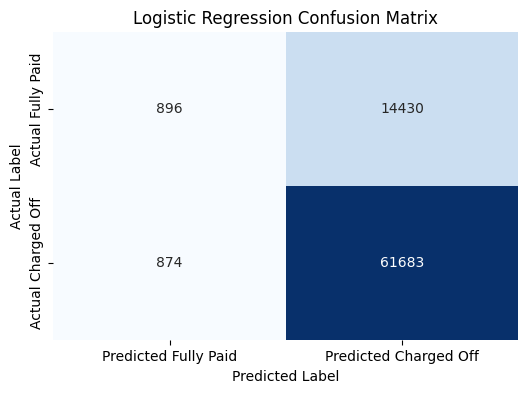

In [23]:
# --- Logistic Regression: Train & Evaluate ---
print('\n--- Machine Learning Model: Logistic Regression ---')
log_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
log_model.fit(X_train_scaled, y_train)
print('Logistic Regression model trained successfully.')

# Evaluation
print('\n--- Model Evaluation: Logistic Regression ---')
y_pred_log = log_model.predict(X_test_scaled)
accuracy_log = accuracy_score(y_test, y_pred_log)
conf_matrix_log = confusion_matrix(y_test, y_pred_log)
class_report_log = classification_report(y_test, y_pred_log)
print(f'Logistic Regression Accuracy: {accuracy_log:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix_log)
print('\nClassification Report:')
print(class_report_log)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fully Paid','Predicted Charged Off'],
            yticklabels=['Actual Fully Paid','Actual Charged Off'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Logistic Regression Interpretation

The logistic regression result is useful as a baseline because it is easy to interpret.

- The accuracy is reasonable, but the confusion matrix shows that the model still misses many charged-off loans.
- For credit risk, that low recall on the charged-off class is the key weakness because false negatives are costly.
- The largest coefficients point to the strongest directional drivers of default risk, especially `interest_rate`, `debt_to_income_ratio`, `loan_income_ratio`, `credit_stress_score`, and `issue_year`.

This model is valuable for interpretability, but it is not the best choice if the main goal is to catch as many risky borrowers as possible.


--- Feature Importance: Logistic Regression Coefficients ---
Top 10 Most Important Features (by absolute coefficient magnitude):
interest_rate                 0.532366
debt_to_income_ratio          0.307289
loan_income_ratio             0.294019
credit_stress_score           0.157509
number_of_open_accounts       0.120770
issue_year                    0.117767
total_credit_lines            0.112639
loan_amount                   0.089638
revolving_balance             0.074200
revolving_line_utilization    0.044250
dtype: float64


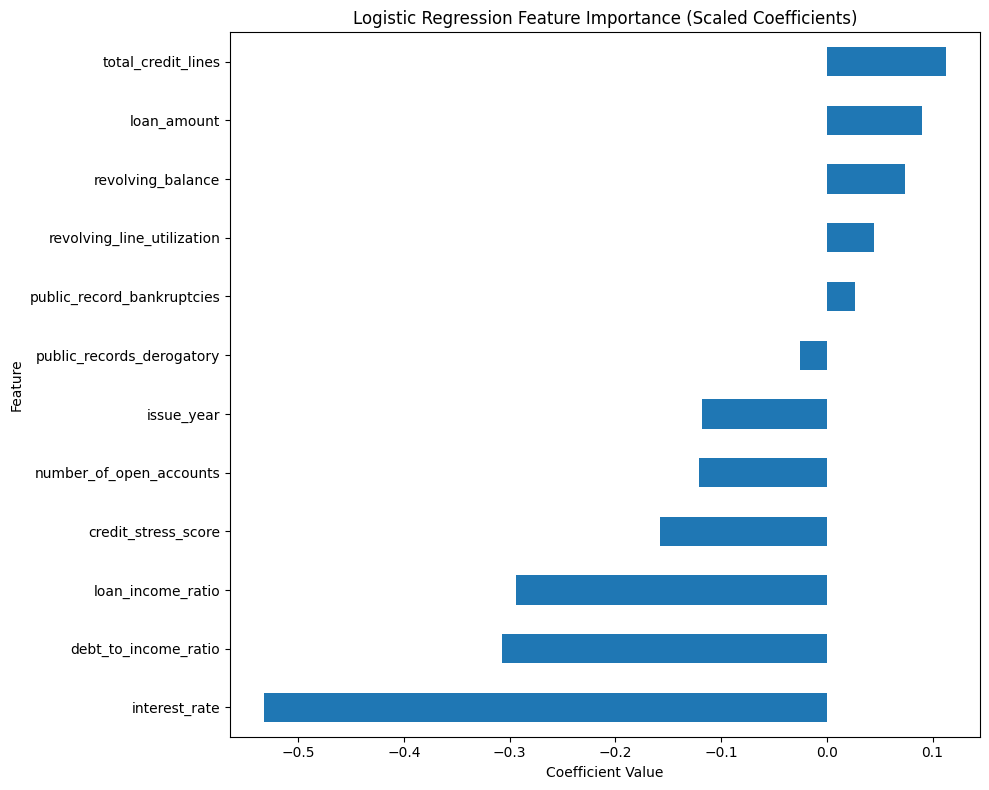

In [24]:
# --- Feature Importance: Logistic Regression Coefficients ---
print('\n--- Feature Importance: Logistic Regression Coefficients ---')
feature_importance_log = pd.Series(log_model.coef_[0], index=X_train.columns)
feature_importance_log_sorted = feature_importance_log.abs().sort_values(ascending=False)
print('Top 10 Most Important Features (by absolute coefficient magnitude):')
print(feature_importance_log_sorted.head(10))
plt.figure(figsize=(10,8))
feature_importance_log.sort_values().tail(20).plot(kind='barh')
plt.title('Logistic Regression Feature Importance (Scaled Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- Advanced Model: Random Forest Classifier ---
Random Forest model trained successfully.
Random Forest Accuracy: 0.8047

Random Forest Confusion Matrix:
[[ 1065 14261]
 [  949 61608]]

Random Forest Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.53      0.07      0.12     15326
  Fully Paid       0.81      0.98      0.89     62557

    accuracy                           0.80     77883
   macro avg       0.67      0.53      0.51     77883
weighted avg       0.76      0.80      0.74     77883



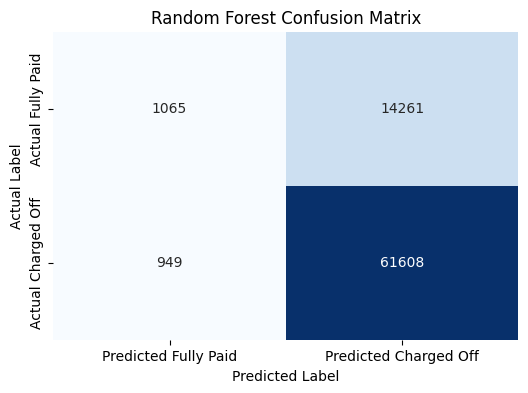

In [25]:
# --- Random Forest: Train & Evaluate ---
print('\n--- Advanced Model: Random Forest Classifier ---')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
print('Random Forest model trained successfully.')

y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print('\nRandom Forest Confusion Matrix:')
print(conf_matrix_rf)
print('\nRandom Forest Classification Report:')
print(class_report_rf)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fully Paid','Predicted Charged Off'],
            yticklabels=['Actual Fully Paid','Actual Charged Off'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Random Forest Interpretation

The random forest performs slightly better than logistic regression in this run, which is expected when the signal is partly non-linear or interactions matter.

- It achieves a small improvement in accuracy.
- It still has limited recall for the charged-off class, so the overall business issue remains the same: default detection is still difficult.
- Compared with logistic regression, it is less interpretable but can capture more complex relationships.

For this dataset, random forest is a stronger predictive baseline, while logistic regression remains the cleaner model for explaining feature directionality.

## Business Insights

1. Income stability matters: borrowers with lower `log_annual_income` are more likely to default, so income remains a core underwriting signal.
2. Debt burden is a major warning sign: higher `debt_to_income_ratio` and `loan_income_ratio` both point to elevated risk.
3. Pricing reflects risk: higher `interest_rate` is strongly associated with worse outcomes, confirming that risk-based pricing is aligned with repayment behavior.
4. Loan grade is informative: lower-grade loans are riskier, which validates the lender’s internal grading system.
5. Past financial distress predicts future distress: `public_record_bankruptcies` and other credit-stress features remain meaningful default indicators.
6. Longer credit history helps: borrowers with stronger repayment histories and more established credit profiles are generally safer.
7. Longer terms carry more uncertainty: 60-month loans are typically riskier than shorter-term loans because exposure lasts longer.

Overall, the workflow shows that statistical testing explains *why* these variables matter, while the models show *how well* they can be used to predict default.